In [1]:
from datetime import datetime, timedelta
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import talib

from samples.myStrategy import myStrategy as baseline_strategy

## Load Data

In [2]:
path = 'data/0050.TW.csv'
df = pd.read_csv(path)

adj_close = df['Adj Close']
date = df['Date']
date_set = set(date)
date_idx = pd.Index(date)

## Analysis

In [3]:
def get_price_interval(beg_idx: int, end_idx: int) -> np.ndarray:
  return adj_close[beg_idx:end_idx + 1].values

def set_title(beg_idx: int, end_idx: int):
  day_num = end_idx - beg_idx + 1
  title = f'{date[beg_idx]} ~ {date[end_idx]}\n{day_num} trade days'
  plt.title(title, fontsize=10)

In [4]:
def plot_rsi(
  close_price: np.ndarray,
  short_period: int, long_period: int
):
  fast = talib.RSI(close_price, timeperiod=short_period)
  slow = talib.RSI(close_price, timeperiod=long_period)

  plt.plot(fast, 'tab:orange')
  plt.plot(slow, 'tab:blue')

def plot_macd(
    close_price: np.ndarray,
    short_period: int, long_period: int, signal_period: int
):
  macd, signal, _ = talib.MACD(close_price, short_period, long_period, signal_period)

  plt.plot(macd, 'tab:blue')
  plt.plot(signal, 'tab:orange')

In [5]:
def plot_actions(close_price: np.ndarray, actions: list):
  buy = []
  sell = []
  for i, action in enumerate(actions):
    if action == 1:
      buy.append(close_price[i])
      sell.append(None)
    elif action == -1:
      buy.append(None)
      sell.append(close_price[i])
    else:
      buy.append(None)
      sell.append(None)

  plt.plot(buy, color='red', marker='^')
  plt.plot(sell, color='green', marker='v')

In [6]:
def get_nearest_workday_idx(date_str: str) -> int:
  ori_date = datetime.strptime(date_str, '%Y-%m-%d')
  date = ori_date

  delta_days = 1

  while date.strftime('%Y-%m-%d') not in date_set:
    date = ori_date + timedelta(days=delta_days)
    delta_days = -delta_days if delta_days > 0 else (-delta_days + 1)

  idx = date_idx.get_loc(date.strftime('%Y-%m-%d'))

  return idx

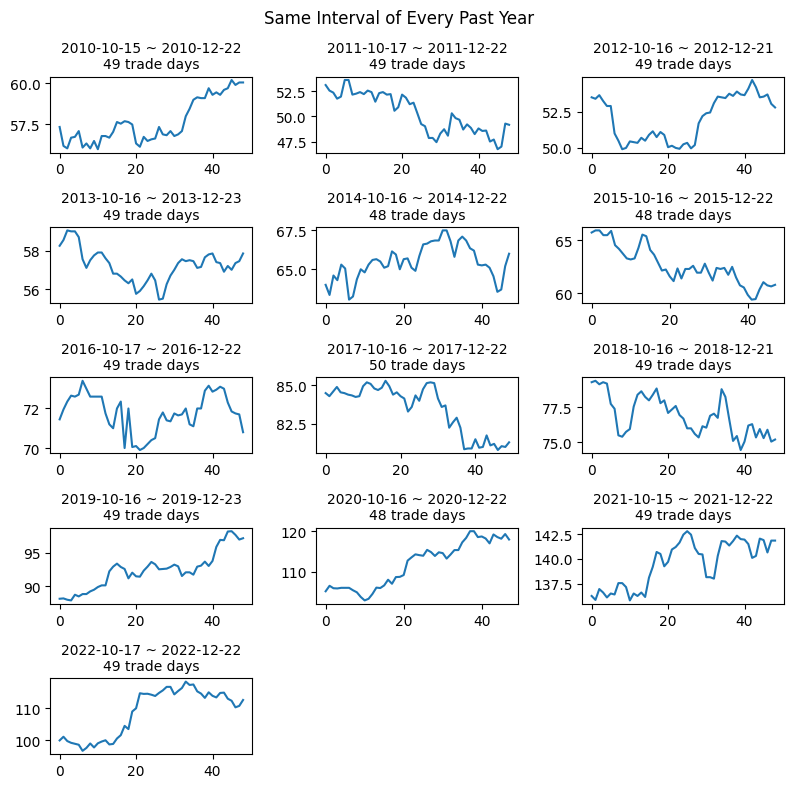

In [7]:
fig = plt.figure(figsize=(8, 8))

for y in range(2010, 2023):
  beg_idx = get_nearest_workday_idx(f'{y}-10-16')
  end_idx = get_nearest_workday_idx(f'{y}-12-22')
  close_price = get_price_interval(beg_idx, end_idx)

  plt.subplot(5, 3, y - 2009)
  set_title(beg_idx, end_idx)
  plt.plot(close_price)

plt.suptitle('Same Interval of Every Past Year')
plt.tight_layout()
plt.show()

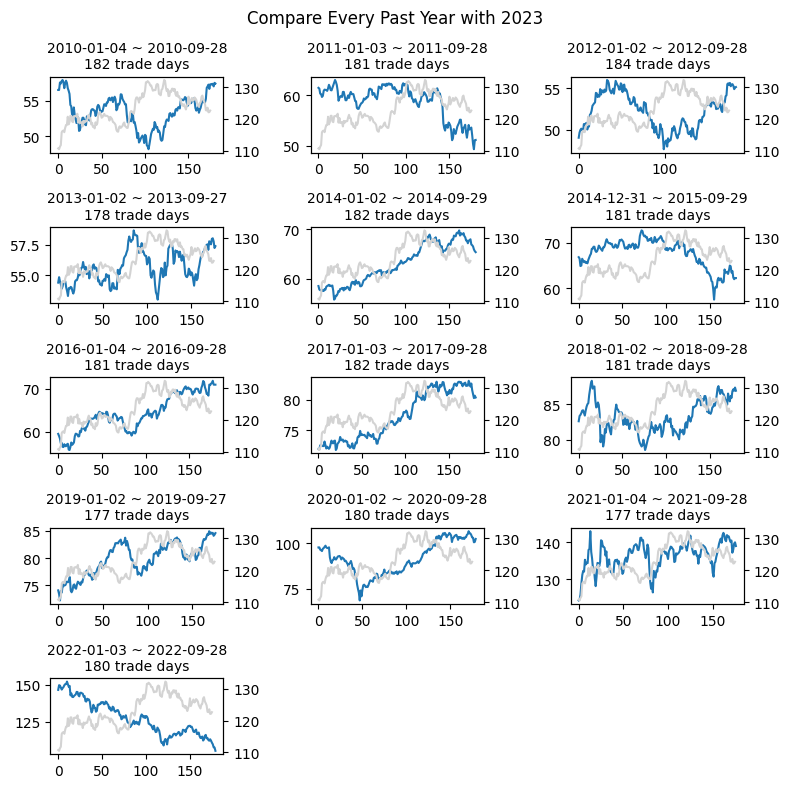

,rho
2017,0.741840
2014,0.727851
2016,0.578945
2019,0.442797
2021,0.404455
2020,0.308456
2013,0.244935
2018,0.096982
2015,-0.180495
2011,-0.237876


In [8]:
fig = plt.figure(figsize=(8, 8))

beg_idx = date_idx.get_loc('2023-01-03')
end_idx = date_idx.get_loc('2023-09-28')
close_price_2023 = get_price_interval(beg_idx, end_idx)

corr_list = pd.Series()

for y in range(2010, 2023):
  beg_idx = get_nearest_workday_idx(f'{y}-01-02')
  end_idx = get_nearest_workday_idx(f'{y}-09-28')
  close_price = get_price_interval(beg_idx, end_idx)

  min_len = min(close_price.shape[0], close_price_2023.shape[0])
  corr = np.corrcoef(close_price[:min_len], close_price_2023[:min_len])[0][1]
  corr_list[y] = corr

  plt.subplot(5, 3, y - 2009)
  set_title(beg_idx, end_idx)
  plt.plot(close_price)
  plt.twinx()
  plt.plot(close_price_2023, 'lightgray')

plt.suptitle(f'Compare Every Past Year with 2023')
plt.tight_layout()
plt.show()

rho = corr_list.sort_values(ascending=False)
pd.DataFrame({ 'rho': rho })

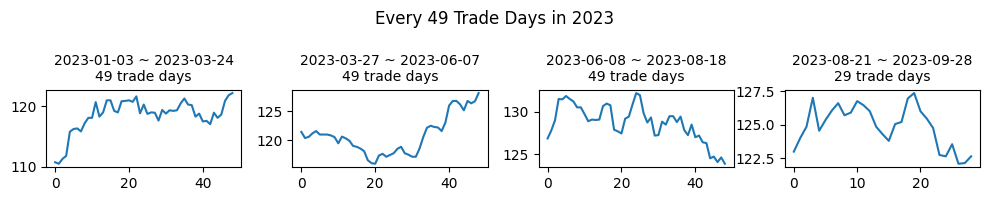

In [9]:
fig = plt.figure(figsize=(10, 2))

n = 49
interval = date[date.str.startswith('2023-')]
splits = [interval[i:i+n] for i in range(0, interval.shape[0], n)]
for i, split in enumerate(splits):
  beg_idx = split[0:1].index[0]
  end_idx = split[-1:].index[0]
  close_price = get_price_interval(beg_idx, end_idx)

  plt.subplot(1, 4, i + 1)
  set_title(beg_idx, end_idx)
  plt.plot(close_price)

plt.suptitle(f'Every {n} Trade Days in 2023')
plt.tight_layout()
plt.show()

## Strategy
### Construction

In [10]:
def get_baseline_strategy_actions(prices: np.ndarray) -> list:
	actions = []

	for i in range(prices.shape[0]):
		past_prices = prices[0:i]
		curr_price = prices[i]
		actions.append(baseline_strategy(past_prices, curr_price))

	return actions

In [11]:
# upper-bound strategy
def get_best_actions(prices: np.ndarray) -> list:
  n = prices.shape[0]
  cash = np.zeros(n)
  stocks = np.zeros(n)
  action_logs = np.zeros((2, n))

  cash[0] = 1000
  stocks[0] = cash[0] / prices[0]
  action_logs[1][0] = 1

  for i in range(1, n):
    new_cash = stocks[i - 1] * prices[i]
    new_stock = cash[i - 1] / prices[i]

    if cash[i - 1] >= new_cash:
      cash[i] = cash[i - 1]
      action_logs[0][i] = 0
    else:
      cash[i] = new_cash
      action_logs[0][i] = -1
    if stocks[i - 1] >= new_stock:
      stocks[i] = stocks[i - 1]
      action_logs[1][i] = 0
    else:
      stocks[i] = new_stock
      action_logs[1][i] = 1

  idx = 0
  actions = []

  for i in range(n - 1, -1, -1):
    if action_logs[idx][i] == 0:
      actions.append(0)
    else:
      actions.append(action_logs[idx][i])
      idx = 1 - idx

  return actions[::-1]

In [12]:
def get_rsi_strategy_actions(
  prices: np.ndarray, beg_idx: int,
  action_rise_above: int, action_fall_below: int,
  fast_ws: int, slow_ws: int
) -> list:
  actions = []

  fast_rsi = talib.RSI(prices, timeperiod=fast_ws)
  slow_rsi = talib.RSI(prices, timeperiod=slow_ws)

  for i in range(beg_idx, prices.shape[0]):
    if fast_rsi[i] > slow_rsi[i] and fast_rsi[i - 1] <= slow_rsi[i - 1]:
      actions.append(action_rise_above)
    elif fast_rsi[i] < slow_rsi[i] and fast_rsi[i - 1] >= slow_rsi[i - 1]:
      actions.append(action_fall_below)
    else:
      actions.append(0)

  return actions

In [13]:
def get_macd_strategy_actions(
  prices: np.ndarray, beg_idx: int,
  action_rise_above: int, action_fall_below: int,
  fastperiod: int, slowperiod: int, signalperiod: int
) -> list:
  actions = []

  macd, signal, _ = talib.MACD(prices, fastperiod, slowperiod, signalperiod)

  for i in range(beg_idx, prices.shape[0]):
    if signal[i] > macd[i] and signal[i - 1] <= macd[i - 1]:
      actions.append(action_rise_above)
    elif signal[i] < macd[i] and signal[i - 1] >= macd[i - 1]:
      actions.append(action_fall_below)
    else:
      actions.append(0)

  return actions

### Fitting

In [14]:
def calculate_return_rate(prices: np.ndarray, actions: list) -> float:
	capital = 1000
	stock_holding = 0

	for i, action in enumerate(actions):
		curr_price = prices[i]
		if action == 1 and capital > 0:
			stock_holding = capital / curr_price
			capital = 0
		elif action == -1 and stock_holding > 0:
			capital = stock_holding * curr_price
			stock_holding = 0

	final = capital + stock_holding * curr_price
	return (final - 1000) / 1000

#### 1. Specify Experiment Interval

In [15]:
exp_interval = date[date.str.startswith('2017-')]
beg_idx = date_idx.get_loc(exp_interval.iat[0])
end_idx = date_idx.get_loc(exp_interval.iat[-1])
exp_interval = get_price_interval(beg_idx, end_idx)
n = 49
exp_splits = [exp_interval[i:i+n] for i in range(0, exp_interval.shape[0], n)]
split_num = len(exp_splits)

#### 2. RSI Strategy

In [16]:
action_rise_above = 1
action_fall_below = -1

best_fast_ws = [ None ] * 2
best_slow_ws = [ None ] * 2

for dir in range(2):
  max_rr = 0

  for fast_ws in range(2, 21):
    for slow_ws in range(fast_ws + 1, 41):
      avg_rr = 0

      for split in exp_splits:
        actions = get_rsi_strategy_actions(
          split, 0,
          action_rise_above, action_fall_below,
          fast_ws, slow_ws
        )
        avg_rr += calculate_return_rate(split, actions)
      avg_rr /= split_num

      if avg_rr > max_rr:
        max_rr = avg_rr
        best_fast_ws[dir] = fast_ws
        best_slow_ws[dir] = slow_ws

  print('[Original]' if dir == 0 else '[Inverse]')
  print(f'Maximized Average Return Rate: {max_rr * 100:.2f}%')
  print('Best Params:')
  print(f'- fast_ws: {best_fast_ws[dir]}')
  print(f'- slow_ws: {best_slow_ws[dir]}')

  action_rise_above, action_fall_below = action_fall_below, action_rise_above

[Original]
Maximized Average Return Rate: 2.19%
Best Params:
- fast_ws: 2
- slow_ws: 5
[Inverse]
Maximized Average Return Rate: 1.88%
Best Params:
- fast_ws: 4
- slow_ws: 11


#### 3. MACD Strategy

In [17]:
action_rise_above = 1
action_fall_below = -1

best_fastperiod = [ None ] * 2
best_slowperiod = [ None ] * 2
best_signalperiod = [ None ] * 2

for dir in range(2):
  max_rr = 0

  for signalperiod in range(1, 21):
    for fastperiod in range(signalperiod + 1, 31):
      for slowperiod in range(fastperiod + 1, 41):
        avg_rr = 0

        for split in exp_splits:
          actions = get_macd_strategy_actions(
            split, 0,
            action_rise_above, action_fall_below,
            fastperiod, slowperiod, signalperiod
          )
          avg_rr += calculate_return_rate(split, actions)
        avg_rr /= split_num

        if avg_rr > max_rr:
          max_rr = avg_rr
          best_fastperiod[dir] = fastperiod
          best_slowperiod[dir] = slowperiod
          best_signalperiod[dir] = signalperiod

  print('[Original]' if dir == 0 else '[Inverse]')
  print(f'Maximized Average Return Rate: {max_rr * 100:.2f}%')
  print('Best Params:')
  print(f'- fastperiod: {best_fastperiod[dir]}')
  print(f'- slowperiod: {best_slowperiod[dir]}')
  print(f'- signalperiod: {best_signalperiod[dir]}')

  action_rise_above, action_fall_below = action_fall_below, action_rise_above

[Original]
Maximized Average Return Rate: 9.69%
Best Params:
- fastperiod: 4
- slowperiod: 5
- signalperiod: 1
[Inverse]
Maximized Average Return Rate: 2.12%
Best Params:
- fastperiod: 5
- slowperiod: 15
- signalperiod: 3


### Testing

In [18]:
get_fitted_rsi_strategy_actions = partial(
  get_rsi_strategy_actions,
  beg_idx=0,
  action_rise_above=1,
  action_fall_below=-1,
  fast_ws=best_fast_ws[0],
  slow_ws=best_slow_ws[0]
)
get_fitted_rsi_inv_strategy_actions = partial(
  get_rsi_strategy_actions,
  beg_idx=0,
  action_rise_above=-1,
  action_fall_below=1,
  fast_ws=best_fast_ws[1],
  slow_ws=best_slow_ws[1]
)
get_fitted_macd_strategy_actions = partial(
  get_macd_strategy_actions,
  beg_idx=0,
  action_rise_above=1,
  action_fall_below=-1,
  fastperiod=best_fastperiod[0],
  slowperiod=best_slowperiod[0],
  signalperiod=best_signalperiod[0]
)
get_fitted_macd_inv_strategy_actions = partial(
  get_macd_strategy_actions,
  beg_idx=0,
  action_rise_above=-1,
  action_fall_below=1,
  fastperiod=best_fastperiod[1],
  slowperiod=best_slowperiod[1],
  signalperiod=best_signalperiod[1]
)

,0,1,2,3,Total,Average
Baseline,4.60%,6.92%,-2.94%,-1.14%,7.44%,2.98%
OPT,27.79%,17.42%,15.10%,10.16%,70.47%,28.19%
RSI,-1.54%,5.13%,-4.61%,-0.93%,-1.96%,-0.78%
RSI_inv,3.57%,1.47%,-2.69%,-2.66%,-0.31%,-0.12%
MACD,11.63%,12.99%,7.47%,3.26%,35.35%,14.14%
MACD_inv,3.46%,4.41%,-0.01%,-1.18%,6.69%,2.68%


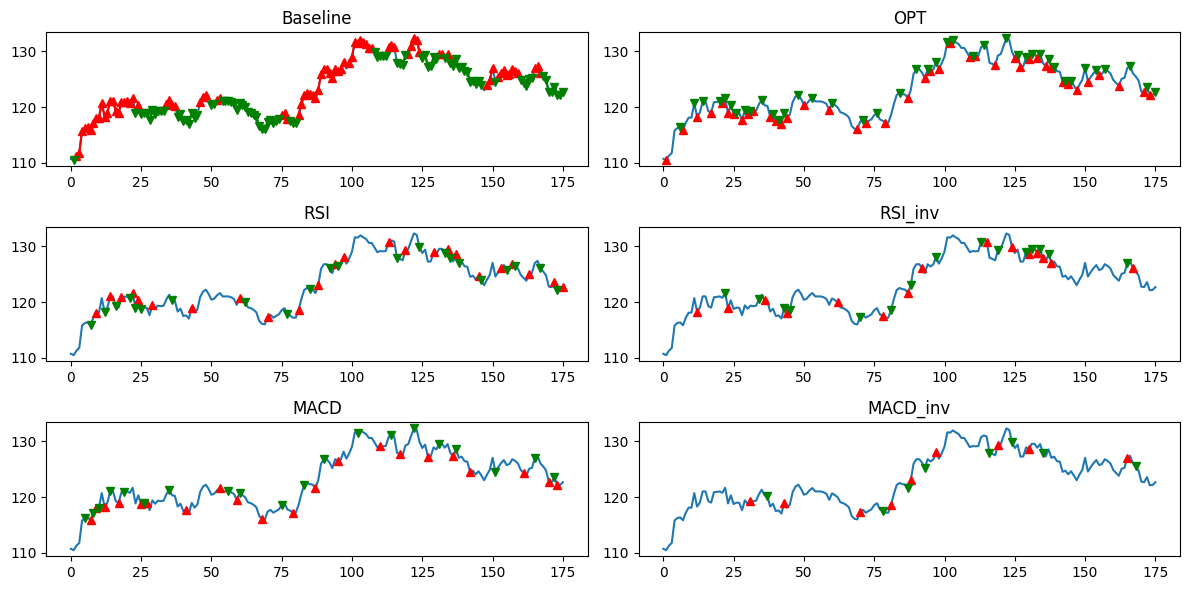

In [19]:
n = 49
interval = adj_close[date.str.startswith('2023-')].values
splits = [interval[i:i+n] for i in range(0, interval.shape[0], n)]

strategies = {
  'Baseline': get_baseline_strategy_actions,
  'OPT': get_best_actions,
  'RSI': get_fitted_rsi_strategy_actions,
  'RSI_inv': get_fitted_rsi_inv_strategy_actions,
  'MACD': get_fitted_macd_strategy_actions,
  'MACD_inv': get_fitted_macd_inv_strategy_actions,
}
strategy_num = len(strategies)

action_list = [[] for _ in range(strategy_num)]
rr_list = [[] for _ in range(strategy_num)]

for split in splits:
  for i, strategy in enumerate(strategies.values()):
    actions = strategy(split)
    rr = calculate_return_rate(split, actions)

    action_list[i] += actions
    rr_list[i].append(rr)

res = pd.DataFrame({ name: rr for name, rr in zip(strategies.keys(), rr_list) })
res = res.transpose() * 100
res['Total'] = res.sum(axis=1)
res['Average'] = res.mean(axis=1)

with pd.option_context('display.float_format', '{:.2f}%'.format):
  display(res)

fig = plt.figure(figsize=(12, 6))

for i, name in enumerate(strategies.keys()):
  plt.subplot(3, 2, i + 1)
  plt.title(name)
  plt.plot(interval)
  plot_actions(interval, action_list[i])

plt.tight_layout()
plt.show()